In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mohammadtalib786/retail-sales-dataset/retail_sales_dataset.csv


“Python was used as the programming language. Pandas was used for data cleaning, transformation, grouping, and revenue calculations. Seaborn and Matplotlib were used for data visualization, including bar charts, count plots, and sales trend charts. Jupyter Notebook was used to write, execute, and document the complete analysis.”

In [2]:
# loading dataset
retail_data = pd.read_csv('/kaggle/input/datasets/mohammadtalib786/retail-sales-dataset/retail_sales_dataset.csv')  

In [3]:
# First 5 rows
retail_data.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [4]:
# dataset size
print(retail_data.shape)

(1000, 9)


In [10]:
# column dtypes
retail_data.dtypes

Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object

In [11]:
# Missing values in each column
retail_data.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [12]:
# For descriptive statistics of numeric columns:
retail_data.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [13]:
numeric_data = retail_data.select_dtypes(include="number")

In [16]:
print('Mean:')
print(numeric_data.mean())

Mean:
Transaction ID    500.500
Age                41.392
Quantity            2.514
Price per Unit    179.890
Total Amount      456.000
dtype: float64


In [18]:
print('Median:')
print(numeric_data.median())

Median:
Transaction ID    500.5
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64


In [25]:
print('Mode:')
print(numeric_data.mode().iloc[0])


Mode:
Transaction ID     1.0
Age               43.0
Quantity           4.0
Price per Unit    50.0
Total Amount      50.0
Name: 0, dtype: float64


In [26]:
print('Standard Deviation:')
print(numeric_data.std())

Standard Deviation:
Transaction ID    288.819436
Age                13.681430
Quantity            1.132734
Price per Unit    189.681356
Total Amount      559.997632
dtype: float64


In [29]:
# First convert the date column into datetime format:
retail_data["Date"] = pd.to_datetime(retail_data["Date"])

# The line chart uses:

 X-axis: Month, such as Jan 2023, Feb 2023
 Y-axis: Total sales amount in that month
 Each point: Sum of all transaction amounts in that month
 Line: Shows whether sales are rising, falling, or fluctuating

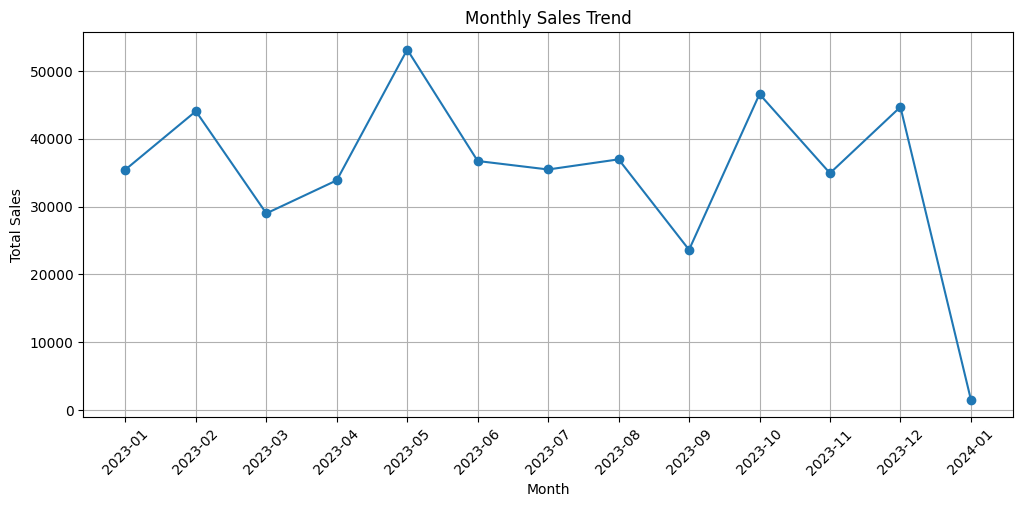

In [39]:
# monthly sales

import matplotlib.pyplot as plt
monthly_sales = (
    retail_data
    .groupby(retail_data["Date"].dt.to_period("M"))["Total Amount"]
    .sum()
)

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index.astype(str), monthly_sales.values, marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid()
plt.show()

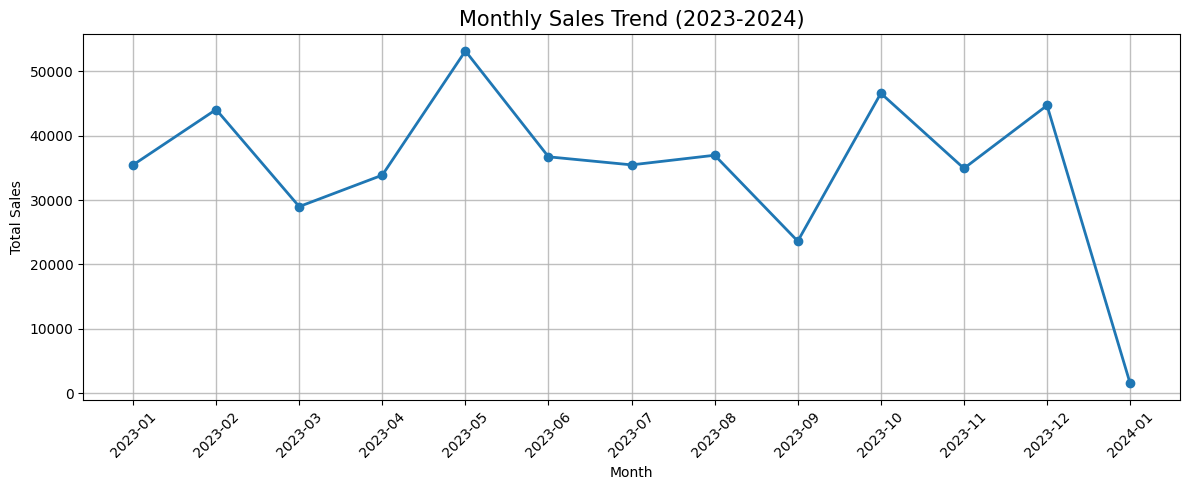

In [49]:
# monthly sales

import matplotlib.pyplot as plt
monthly_sales = (
    retail_data                                                           #retail_data["Date"].dt.to_period("M") --> This extracts the year and month from every date.
    .groupby(retail_data["Date"].dt.to_period("M"))["Total Amount"]       #.groupby(...) --> puts all transactions from the same month together. 
    .sum()                                                                #["Total Amount"].sum() --> adds the sales values in each month.
)

plt.figure(figsize=(12,5))
plt.plot(monthly_sales.index.astype(str),
         monthly_sales.values,
         marker='o',
         linewidth=2)

plt.title("Monthly Sales Trend (2023-2024)", fontsize=15)
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(alpha=0.8, linewidth=1)
plt.tight_layout()

plt.savefig("monthly_sales_trend.png", dpi=300)
plt.show()

# Observation
Sales performance in 2023 was inconsistent but generally healthy, averaging around 37,000 units per month, with clear peak periods in spring (May) and autumn (October). The apparent drop in January 2024 warrants further investigation to confirm whether it reflects a true business downturn or a data completeness issue.

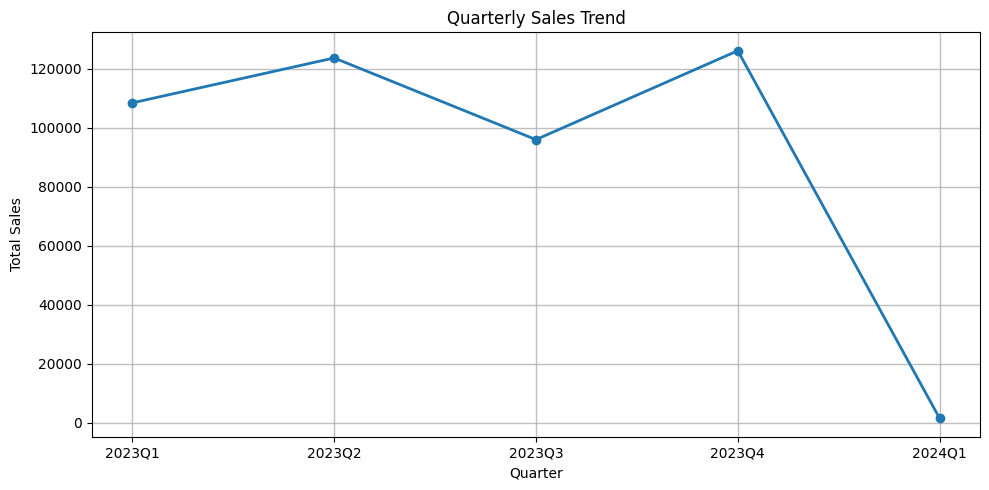

In [48]:
quarterly_sales = (
    retail_data
    .groupby(retail_data["Date"].dt.to_period("Q"))["Total Amount"]  #retail_data["Date"].dt.to_period("Q") --> This converts every date into its year-quarter label.
    .sum()                                                           #.groupby(...) --> collects all transactions with the same quarter label together.
)                                                                    #["Total Amount"].sum() --> adds the transaction amounts within each quarter.
plt.figure(figsize=(10, 5))

plt.plot(
    quarterly_sales.index.astype(str),
    quarterly_sales.values,
    marker="o",
    linewidth=2
)

plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")
plt.grid(alpha=0.8, linewidth=1)
plt.tight_layout()
plt.show()

# Observation:
Quarterly sales in 2023 followed a healthy pattern of growth, a mid-year dip, and a strong year-end recovery, averaging around 113,700 units per quarter across the four full quarters. The sharp Q1 2024 drop is best treated as a data artifact rather than a real trend until verified.

Age Group Distribution:
Age Group
Under 18      0
18-25       149
26-35       203
36-45       207
46-55       225
56+         216
Name: count, dtype: int64


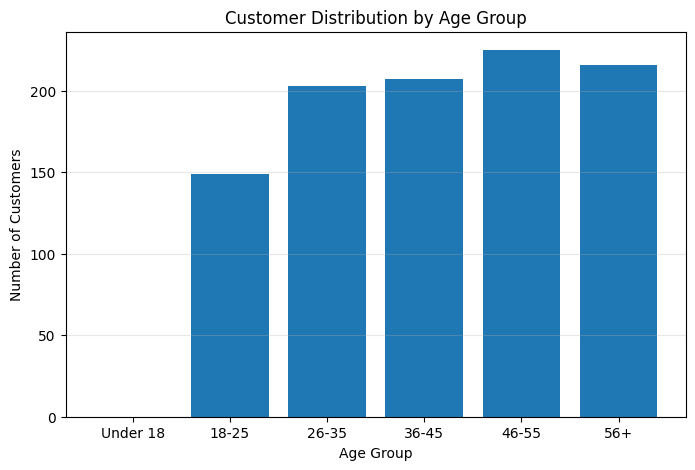

In [13]:
# Customer demographics analysis

import matplotlib.pyplot as plt

age_bins = [0, 18, 25, 35, 45, 55, 100]         # Create age groups 
age_labels = ["Under 18", "18-25", "26-35", "36-45", "46-55", "56+"]

retail_data["Age Group"] = pd.cut(      # pd.cut() : divides continuous values into categories.
    retail_data["Age"],
    bins=age_bins,
    labels=age_labels,
    right=False                         # right=False means the upper number is excluded
)

age_group_counts = retail_data["Age Group"].value_counts().sort_index()    # value_counts() counts how many records belong to each age group
print("Age Group Distribution:")
print(age_group_counts)

# Plot age group distribution

plt.figure(figsize=(8, 5))
plt.bar(age_group_counts.index.astype(str), age_group_counts.values)

plt.title("Customer Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.grid(axis='y', alpha=0.3)
plt.show()

# Observation:
The 46-55 age group has the highest number of customers (225).
There are no customers below 18 years old.
Customers aged 36 and above form the major customer segment.

Gender
Female    510
Male      490
Name: count, dtype: int64


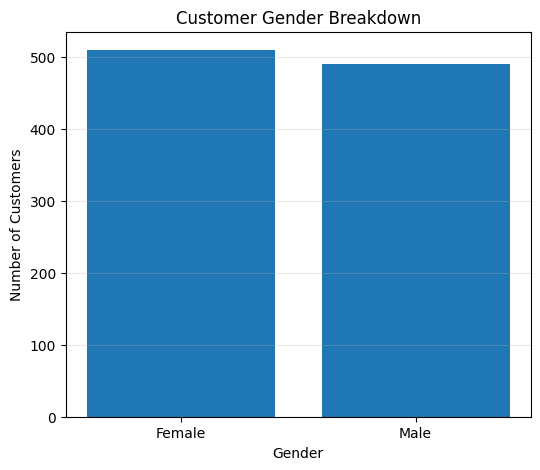

In [6]:
# Gender breakdown : Gender breakdown shows how transactions or customers are distributed across gender categories.

gender_counts = retail_data["Gender"].value_counts()    # Count transactions by gender
print(gender_counts)

# Plot gender breakdown

plt.figure(figsize=(6, 5))
plt.bar(gender_counts.index.astype(str), gender_counts.values)

plt.title("Customer Gender Breakdown")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.grid(axis='y', alpha=0.3)
plt.show()

# Observation
Female customers accounted for a slightly larger share of transactions than male customers. However, the difference is small, indicating that the customer base is relatively balanced by gender.

['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount', 'Age Group']
Top 10 Best-Selling Products Categories:
Product Category
Clothing       894
Electronics    849
Beauty         771
Name: Quantity, dtype: int64


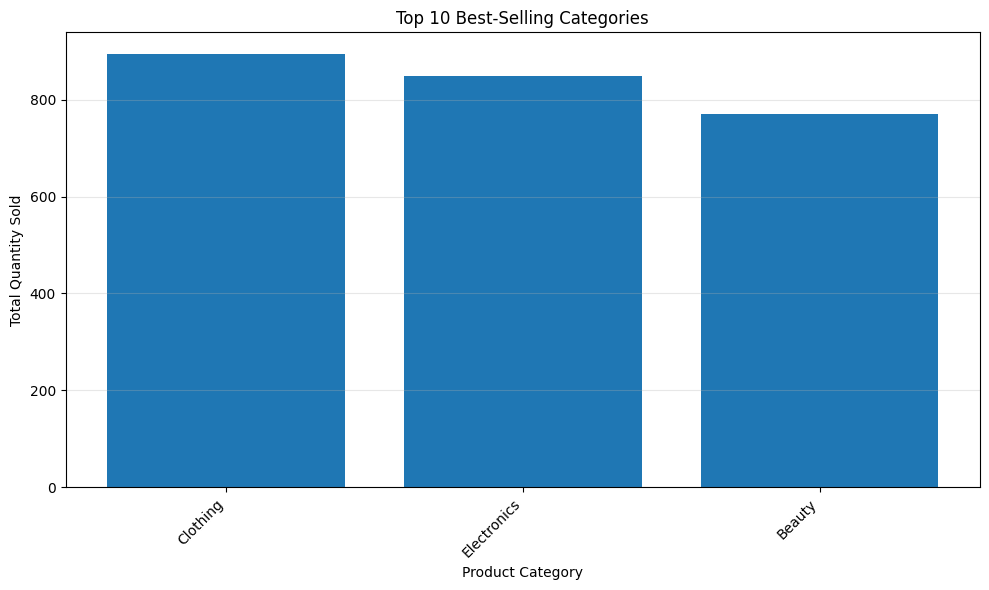

In [10]:
# PRODUCT ANALYSIS:

import matplotlib.pyplot as plt

# Remove extra spaces from column names
retail_data.columns = retail_data.columns.str.strip()

# Check your column names
print(retail_data.columns.tolist())

# -------------------------------
# 1. Top 10 Best-Selling Products
# -------------------------------

# Total quantity sold for each product

top_categories = (
    retail_data.groupby('Product Category')['Quantity']   # This groups all rows with the same product name and adds their sold quantity
      .sum()
      .sort_values(ascending=False)     # sort_values(ascending=False) puts the highest-selling products first
      .head(10)                         # head(10) selects only the top 10 products
)

print("Top 10 Best-Selling Products Categories:")
print(top_categories)

# Bar chart for top 10 products
plt.figure(figsize=(10, 6))
plt.bar(top_categories.index.astype(str), top_categories.values)

plt.title("Top 10 Best-Selling Categories")
plt.xlabel("Product Category")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

  Product Category  Total Amount
0      Electronics        156905
1         Clothing        155580
2           Beauty        143515


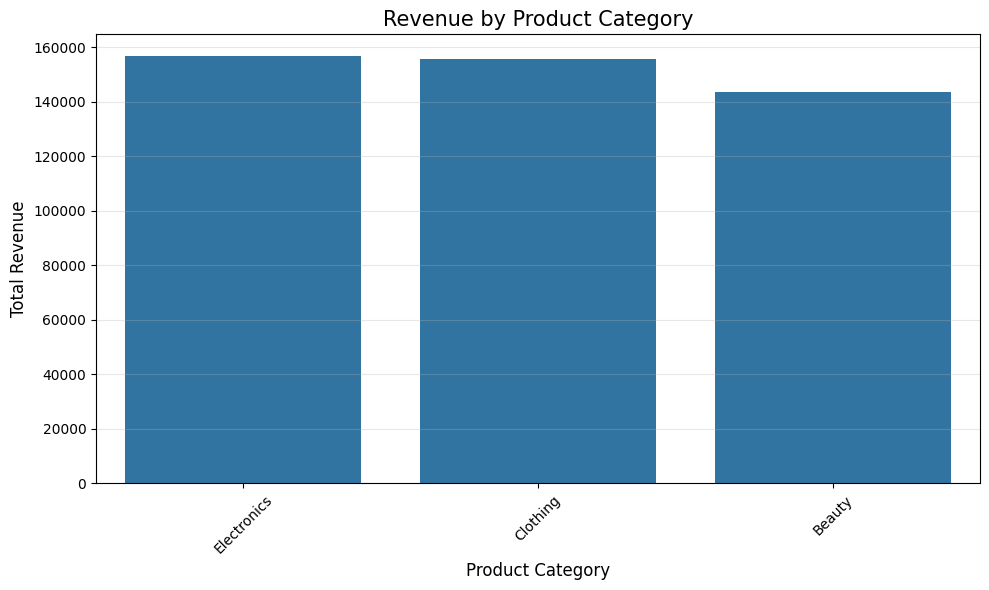

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# Remove extra spaces from column names
retail_data.columns = retail_data.columns.str.strip()

# -------------------------------
# 2. Revenue By Product Category
# -------------------------------

# Calculate total revenue for each product category
category_revenue = (
    retail_data.groupby('Product Category')['Total Amount']    # groupby('Product Category') puts all rows with the same category together , ['Total Amount'] selects only the sales amount column.
    .sum()                                                     # .sum() adds all sales amounts within each category.
    .sort_values(ascending=False)                              # sorts categories from highest revenue to lowest revenue.                            
    .reset_index()                                             # converts the result into a proper DataFrame so Seaborn can use it easily.
)

# Display revenue values
print(category_revenue)

# Create bar chart using Seaborn
plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_revenue,                                   # data=category_revenue tells Seaborn which DataFrame to use.
    x='Product Category',                                    # x='Product Category' puts category names on the horizontal axis. 
    y='Total Amount'                                         # y='Total Amount' puts revenue values on the vertical axis.
)

plt.title("Revenue by Product Category", fontsize=15)
plt.xlabel("Product Category", fontsize=12)
plt.ylabel("Total Revenue", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Observation:
Electronics generated the highest revenue, followed closely by Clothing.
Beauty generated the lowest revenue, but all categories contributed strongly to total sales.

# What is a correlation matrix?
A correlation matrix shows the relationship between numerical columns, such as:

Age,
Quantity,
Price per Unit,
Total Amount

Each value is between -1 and +1.

['Transaction ID', 'Age', 'Quantity', 'Price per Unit', 'Total Amount']
                Transaction ID       Age  Quantity  Price per Unit  \
Transaction ID        1.000000  0.065191 -0.026623       -0.060837   
Age                   0.065191  1.000000 -0.023737       -0.038423   
Quantity             -0.026623 -0.023737  1.000000        0.017501   
Price per Unit       -0.060837 -0.038423  0.017501        1.000000   
Total Amount         -0.075034 -0.060568  0.373707        0.851925   

                Total Amount  
Transaction ID     -0.075034  
Age                -0.060568  
Quantity            0.373707  
Price per Unit      0.851925  
Total Amount        1.000000  


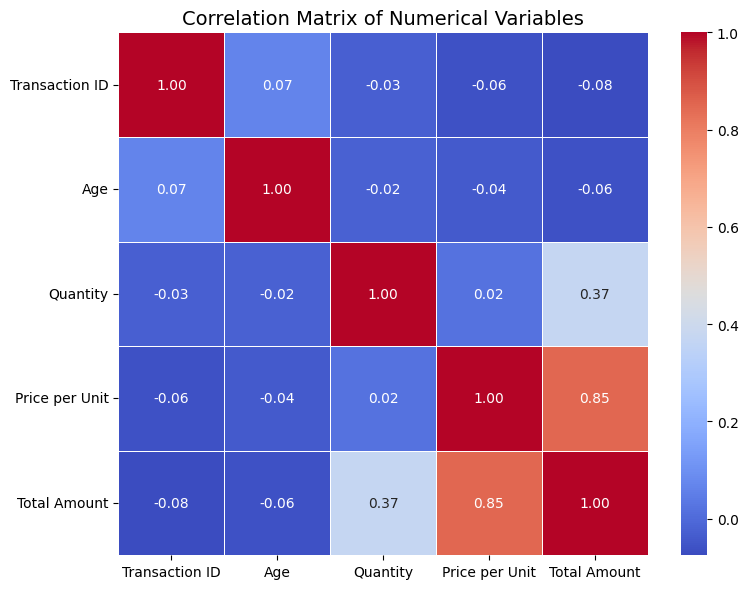

In [4]:
# Heatmap

import seaborn as sns
import matplotlib.pyplot as plt

# Select only numerical columns from the dataset
numerical_data = retail_data.select_dtypes(include='number')

# Display the numerical columns selected
print(numerical_data.columns.tolist())

# Calculate correlation between numerical variables
correlation_matrix = numerical_data.corr()

# Display correlation values
print(correlation_matrix)

# Create heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,          # shows correlation values inside boxes
    cmap='coolwarm',     # color style
    fmt='.2f',           # shows values up to 2 decimal places
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Variables", fontsize=14)
plt.tight_layout()
plt.show()

# Observation:
The correlation matrix reveals that Price per Unit and Total Amount have a strong positive correlation (0.85), which is expected since total amount is largely driven by price. Quantity and Total Amount show a moderate positive correlation (0.37), indicating quantity also contributes to the total amount but less strongly than price.
All other variables — Transaction ID, Age, and their relationships with other features — show very weak or negligible correlations (values close to 0), suggesting these variables are largely independent of one another and do not significantly influence each other.
Overall, Total Amount is primarily driven by Price per Unit, with a smaller contribution from Quantity, while demographic/identifier variables (Age, Transaction ID) have no meaningful linear relationship with the transaction metrics.

  Product Category  Gender  Total Amount
0           Beauty  Female    450.783133
1           Beauty    Male    487.127660
2         Clothing  Female    467.097701
3         Clothing    Male    419.802260
4      Electronics  Female    451.382353
5      Electronics    Male    466.104651


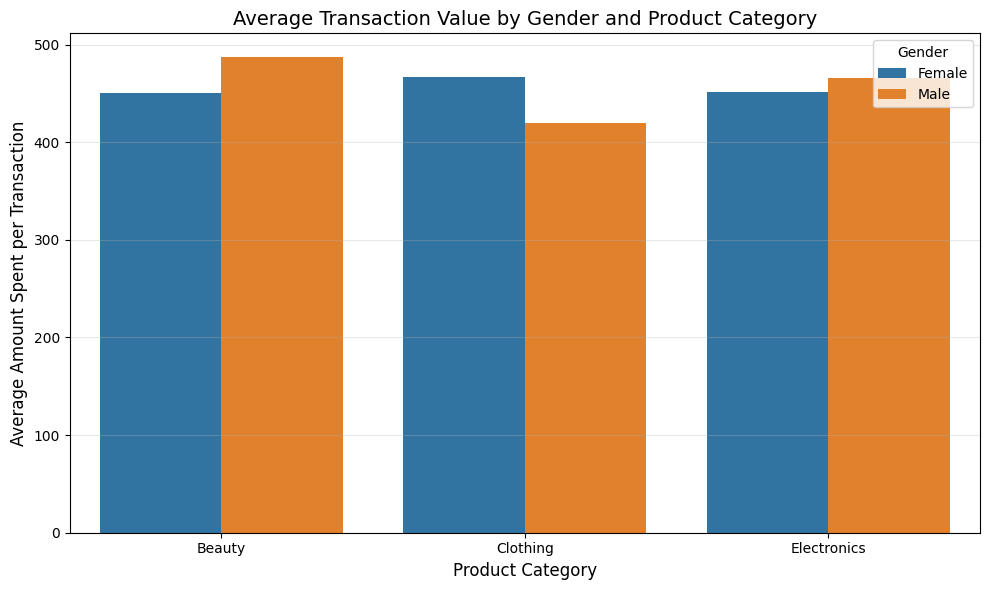

In [5]:
#  one additional visualisation :
#1. Average Transaction Value by Gender and Product Category : a category may have lower total revenue but still have customers who spend more per purchase.

import seaborn as sns
import matplotlib.pyplot as plt

# Calculate average transaction value for each gender-category combination
avg_spend = (
    retail_data.groupby(['Product Category', 'Gender'])['Total Amount']       # creates groups using both category and gender
    .mean()                                                                   # average amount spent in one transaction, rather than the total amount from all transactions
    .reset_index()                                                            # converts the result into a DataFrame that Seaborn can plot
)

print(avg_spend)

# Create grouped bar chart
plt.figure(figsize=(10, 6))

sns.barplot(
    data=avg_spend,
    x='Product Category',
    y='Total Amount',
    hue='Gender'                                                               # This creates separate bars for each gender inside every product category
)

plt.title("Average Transaction Value by Gender and Product Category", fontsize=14)
plt.xlabel("Product Category", fontsize=12)
plt.ylabel("Average Amount Spent per Transaction", fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


# Observation:
The chart shows that average spending differs by both gender and product category. Male customers have the highest average transaction value in the Beauty category, at approximately 490, compared with around 450 for female customers. In Electronics, male customers also spend slightly more on average than female customers.

However, in the Clothing category, female customers have a higher average transaction value, around 465, while male customers spend approximately 420 per transaction. This suggests that male customers tend to spend more on Beauty and Electronics products, whereas female customers spend more on Clothing products.

This insight can help the business create targeted promotions: Beauty and Electronics offers can be designed to encourage higher-value male purchases, while Clothing recommendations and loyalty offers can be focused more toward female customers.

        Month  Total Amount
0     January         36980
1    February         44060
2       March         28990
3       April         33870
4         May         53150
5        June         36715
6        July         35465
7      August         36960
8   September         23620
9     October         46580
10   November         34920
11   December         44690


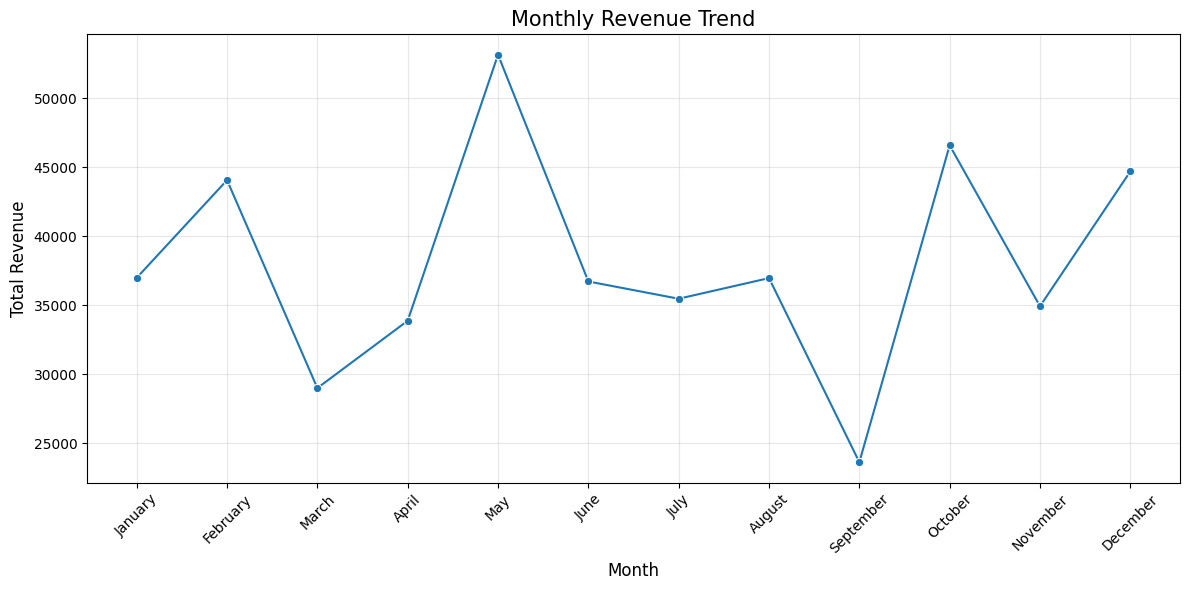

In [7]:
# 2. Monthly Sales Trend : reveal which months have unusually high or low revenue, helping the business plan stock and offers.

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert Date column into datetime format
retail_data['Date'] = pd.to_datetime(retail_data['Date'])    # This converts the date column from text into a proper date format so Python can extract the month

# Create a month column
retail_data['Month'] = retail_data['Date'].dt.month_name()    # This takes the month name from each transaction date, such as January, February, or March

# Keep months in correct calendar order
month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

# Calculate total revenue for each month
monthly_revenue = (
    retail_data.groupby('Month')['Total Amount']              # This groups all transactions from the same month and adds their revenue
    .sum()
    .reindex(month_order)                                     # Without this, months may appear alphabetically, such as April, August, December. This keeps them in calendar order
    .dropna()
    .reset_index()
)

print(monthly_revenue)

# Create line chart
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_revenue,
    x='Month',
    y='Total Amount',
    marker='o'
)

plt.title("Monthly Revenue Trend", fontsize=15)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Total Revenue", fontsize=12)
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

 # Observation:
The monthly revenue trend shows noticeable variation in sales throughout the year. May recorded the highest revenue, approximately 53,000, making it the strongest sales month. October and December also performed well, with revenue around 46,000 and 44,700 respectively.

The lowest revenue was recorded in September, at approximately 23,500. March also had relatively low revenue, around 29,000. This indicates that sales may be affected by seasonal demand, customer purchasing patterns, or promotional activity during different months.

The business can prepare higher inventory and stronger marketing campaigns before high-performing months such as May, October, and December. For lower-performing months like March and September, it can introduce discounts, bundle offers, or special campaigns to encourage more customer purchases.

# Conclusion and Recommendations

The analysis gives a clear view of customer behaviour and category performance. Most customers belong to the age range of 36 years and above, with the 46–55 group being the largest. This suggests that the business should design advertisements, discounts, and loyalty benefits that appeal to mature customers. Personalized offers and repeat-customer rewards may help increase their engagement and encourage more frequent purchases.

Revenue results show that Electronics and Clothing are the strongest-performing categories. Since these categories bring in the most income, the business should keep sufficient stock available and avoid shortages. It can also introduce product bundles, such as electronic accessories with devices or complementary clothing items, to increase the value of each purchase.

The Beauty category earns comparatively less revenue than the other categories. Rather than reducing focus on it, the business can improve its sales through limited-time discounts, combo offers, sample products, and recommendations during checkout. Pairing Beauty items with Clothing purchases may also encourage customers to explore more products.

The correlation analysis indicates that transaction value is mainly influenced by purchase quantity and product price. Therefore, the company can test pricing strategies such as volume discounts, “buy more and save more” offers, or category-specific deals. These strategies may increase the number of items purchased while keeping overall revenue strong.

Overall, the business should focus on its major customer age groups, protect the performance of high-revenue categories, and use targeted promotions to strengthen lower-performing categories.